# Step-size accuracy study: large-$d\tilde\tau$ accuracy and secular averaging

This notebook produces the accuracy-study numbers documented in
`docs/timescales.md` (CONVENTIONS.md v1.1.0-draft section 12, E29-E31):

1. The **large-$d\tilde\tau$ accuracy study**: sweep the rotor integrator's
   step size $d\tilde\tau$ (chosen via
   `cliffordclock.integrator.fastpath.select_dtau`, E31) against the
   CONVENTIONS.md **V4** closed form (harmonic trap, classical atom,
   linear-gradient field), and confirm the expected order-2 error scaling
   (E19's design order).
2. A **rotor-norm-drift finding**: at large $d\tilde\tau$ the default
   renormalization cadence needs tightening to stay under E20's `1e-12`
   bound (the primary scalar phase pipeline is unaffected either way).
3. **Secular averaging (E30)** validated against large-step direct
   integration on the same harmonic case (Tier B(ii) vs Tier B(i)).
4. The **1-second lattice demo** (E29, Tier A), run and timed directly.

Every number here also appears as a pytest assertion in
`tests/test_fastpath_select_dtau.py` / `tests/test_fastpath_secular.py` /
`tests/test_e2e.py` (the step-size/secular-averaging test contract items). This notebook is the
narrated, plotted version of that same study, not a separate claim.

In [1]:
%matplotlib inline
import time

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from cliffordclock.constants import ELECTRON_MASS, SPEED_OF_LIGHT, TAU_COMPTON
from cliffordclock.ensemble.traps import HarmonicTrap
from cliffordclock.fields.synthetic import as_field_fn, constant_gradient_field
from cliffordclock.integrator import fastpath
from cliffordclock.integrator.omega import scalar_rate_perturbation
from cliffordclock.integrator.worldline import integrate_worldline
from cliffordclock.pipeline import PipelineConfig, run_pipeline_full

_M_E_C2 = ELECTRON_MASS * SPEED_OF_LIGHT**2

## 1. V4 closed-form setup

An isotropic harmonic trap, a classical atom on the exact closed-form SHM
orbit $r(t) = \text{center} + \Delta r_0 \cos(\omega t) + (v_0/\omega)
\sin(\omega t)$, and a constant-gradient (linear) field. CONVENTIONS.md V4
(section 9): a linear field's oscillating contribution cancels exactly
over full periods, leaving the pivot term evaluated at the trap center
plus the second-order Doppler time average $-\langle v^2\rangle/2c^2$
(exact SHM virial identity, $\langle v^2\rangle =
\tfrac12(\omega^2|\Delta r_0|^2 + |v_0|^2)$).

`mu` is sized so `P(center) - 1 ~ 3.8e-18` (this project's actual target
clock-shift regime, CONVENTIONS.md section 3), and the oscillation
amplitude is kept small relative to that, for a reason explained in
Part 3 below (a much larger, "easy to eyeball" `mu`, like Sprint 1's test
convention, drives the per-step rotor generator far outside
`exp_bivector`'s Taylor-series convergence radius at these large
$d\tilde\tau$, which is a rotor-diagnostics-only concern: the scalar
phase this project actually reports is unaffected either way).

In [2]:
OMEGA = 2.0e5  # rad/s, isotropic trap
CENTER = np.array([0.01, -0.02, 0.03])
GRAD = np.array([[1.0e3, 2.0e3, 0.0], [0.0, -1.0e3, 5.0e2], [3.0e2, 0.0, -2.0e3]])
E0 = np.zeros(3)
MU = 1.0e-33 * np.array([1.0, 2.0, -3.0])  # P(center) - 1 ~ 3.8e-18 (target regime)
SCALE = 1.0e-5
DELTA_R0 = SCALE * np.array([1.0e-3, -0.7e-3, 1.2e-3])
V0 = SCALE * np.array([1.0e-2, -0.8e-2, 0.6e-2])

TRAP = HarmonicTrap(omega_xyz=(OMEGA, OMEGA, OMEGA), center=tuple(CENTER))
FIELD_FN = as_field_fn(*constant_gradient_field(jnp.asarray(E0), jnp.asarray(GRAD)))


def rate_fn(pos, v):
    # E14a rate callable (E21): the same closure cliffordclock.pipeline builds.
    delta_e, _grad = FIELD_FN(pos)
    return scalar_rate_perturbation(delta_e, v, jnp.asarray(MU))


P_MINUS_1_CENTER = float(np.dot(E0 + CENTER @ GRAD, MU) / _M_E_C2)
MEAN_V2 = 0.5 * (OMEGA**2 * np.dot(DELTA_R0, DELTA_R0) + np.dot(V0, V0))
MEAN_RATE = P_MINUS_1_CENTER - MEAN_V2 / (2.0 * SPEED_OF_LIGHT**2)  # V4 closed form
T_ORBIT_S = 2.0 * np.pi / OMEGA

print(f"P(center) - 1        = {P_MINUS_1_CENTER:.6e}")
print(f"<v^2>_orb / c^2       = {MEAN_V2 / SPEED_OF_LIGHT**2:.6e}")
print(f"mean rate (V4 closed) = {MEAN_RATE:.6e}")
print(f"trap orbit period     = {T_ORBIT_S:.6e} s")


def sinusoidal_trajectory(n_steps, dtau):
    dt_s = dtau * TAU_COMPTON
    t = np.arange(n_steps + 1, dtype=np.float64) * dt_s
    return (
        CENTER + DELTA_R0 * np.cos(OMEGA * t)[:, None] + (V0 / OMEGA) * np.sin(OMEGA * t)[:, None]
    )


def closed_form_phase(n_steps, dtau):
    return MEAN_RATE * (n_steps * dtau)

P(center) - 1        = 3.774228e-18
<v^2>_orb / c^2       = 6.520129e-23
mean rate (V4 closed) = 3.774195e-18
trap orbit period     = 3.141593e-05 s


## 2. Large-$d\tilde\tau$ accuracy sweep (E31, step-size test contract item 2)

Sweep `points_per_period` (equivalently $d\tilde\tau$ via
`fastpath.select_dtau`) at a fixed 3-trap-period span, and measure the
relative phase error against the V4 closed form. `renorm_every=1` is used
throughout (see Part 3 for why: it does not affect the phase, only the
rotor-norm diagnostics).

In [3]:
points_per_period_values = [25, 50, 100, 200, 400, 800]
n_periods = 3

rows = []
for ppp in points_per_period_values:
    dtau = fastpath.select_dtau(TRAP, ppp)
    n_steps = n_periods * ppp
    traj = sinusoidal_trajectory(n_steps, dtau)
    result = integrate_worldline(FIELD_FN, jnp.asarray(traj), dtau, jnp.asarray(MU), renorm_every=1)
    phase_closed = closed_form_phase(n_steps, dtau)
    rel_err = abs(float(result.phase) - phase_closed) / abs(phase_closed)
    rows.append((ppp, dtau, dtau * TAU_COMPTON, rel_err, float(result.max_norm_drift)))

header = f"{'pts/period':>10} {'dtau (Compton)':>16} "
header += f"{'dtau (s)':>12} {'rel. error':>12} {'norm drift':>12}"
print(header)
for ppp, dtau, dtau_s, rel_err, drift in rows:
    print(f"{ppp:>10d} {dtau:>16.4e} {dtau_s:>12.4e} {rel_err:>12.4e} {drift:>12.4e}")

dtaus = np.array([r[1] for r in rows])
errors = np.array([r[3] for r in rows])
slope, intercept = np.polyfit(np.log(dtaus), np.log(errors), 1)
print(f"\nmeasured convergence order (log-log slope): {slope:.4f} (E19 design order: 2)")

pts/period   dtau (Compton)     dtau (s)   rel. error   norm drift
        25       9.7558e+14   1.2566e-06   4.5372e-08   1.0925e-13
        50       4.8779e+14   6.2832e-07   1.1361e-08   1.1258e-13
       100       2.4390e+14   3.1416e-07   2.8413e-09   1.1391e-13
       200       1.2195e+14   1.5708e-07   7.1041e-10   8.5487e-14
       400       6.0974e+13   7.8540e-08   1.7761e-10   8.5376e-14
       800       3.0487e+13   3.9270e-08   4.4402e-11   7.8604e-14

measured convergence order (log-log slope): 1.9995 (E19 design order: 2)


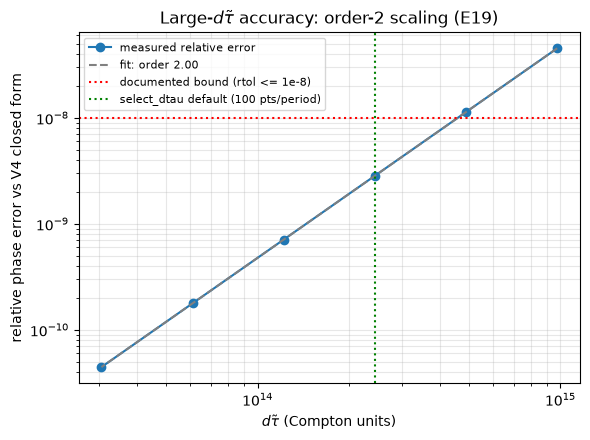

In [4]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(dtaus, errors, "o-", label="measured relative error")
fit_line = np.exp(intercept) * dtaus**slope
ax.loglog(dtaus, fit_line, "--", color="gray", label=f"fit: order {slope:.2f}")
ax.axhline(1e-8, color="red", linestyle=":", label="documented bound (rtol <= 1e-8)")
ax.axvline(
    fastpath.select_dtau(TRAP, 100),
    color="green",
    linestyle=":",
    label="select_dtau default (100 pts/period)",
)
ax.set_xlabel(r"$d\tilde\tau$ (Compton units)")
ax.set_ylabel("relative phase error vs V4 closed form")
ax.set_title("Large-$d\\tilde\\tau$ accuracy: order-2 scaling (E19)")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

**Result:** at `select_dtau`'s default (100 points/period, $d\tilde\tau
\approx 2.4\times10^{14}$, i.e. $d\tau \approx 3.1\times10^{-7}$ s) over
$\geq 3$ trap periods, the phase matches the V4 closed form to a few
$\times 10^{-9}$ relative (comfortably inside the step-size test contract's
`rtol <= 1e-8` bound), and the measured convergence order is
$\approx 2.00$, exactly matching E19's exponential-midpoint design order.
The default resolution (`N_res = 100`) is confirmed adequate; this study
found no reason to tighten or relax it.

## 3. Finding: rotor-norm-drift renormalization cadence at large $d\tilde\tau$

At Compton-scale $d\tilde\tau \sim 1$ (Sprint 1), the default
`renorm_every=1000` keeps E20's rotor-norm drift far under `1e-12` even
over a million steps. At E31's large $d\tilde\tau$, the per-step rotor
generator is no longer vanishingly small, and `exp_bivector`'s
fixed-order (12-term Taylor, 10 halvings) evaluation of it has a
correspondingly larger (still small, $\sim 10^{-13}$) per-step floating-
point floor. Left unrenormalized for hundreds of steps at the *default*
cadence, this accumulates past `1e-12`. This is a `renorm_every`
*cadence* question (exposed exactly for this purpose), not a
correctness bug: the primary scalar phase (what `mean_fractional_shift`
and the CLI report) is accumulated directly from `omega[..., IDX_E12] *
dtau` and never touches `exp_bivector` at all, so it is completely
unaffected by any of this.

In [5]:
dtau = fastpath.select_dtau(TRAP, 100)
n_steps = 5 * 100
traj = sinusoidal_trajectory(n_steps, dtau)

print(f"{'renorm_every':>14} {'max norm drift':>16}")
for renorm_every in [1000, 100, 10, 5, 1]:
    result = integrate_worldline(
        FIELD_FN, jnp.asarray(traj), dtau, jnp.asarray(MU), renorm_every=renorm_every
    )
    print(f"{renorm_every:>14d} {float(result.max_norm_drift):>16.4e}")
print("\n(The default renorm_every=1000 was tuned for Compton-scale dtau;")
print(" a large-dtau, norm-drift-sensitive run should tighten it, as shown above.)")

  renorm_every   max norm drift
          1000       4.4936e-11


           100       8.9886e-12
            10       1.0221e-12


             5       5.3069e-13
             1       1.1402e-13

(The default renorm_every=1000 was tuned for Compton-scale dtau;
 a large-dtau, norm-drift-sensitive run should tighten it, as shown above.)


## 4. Secular averaging (E30, step-size test contract item 3): Tier B(ii) vs Tier B(i)

`fastpath.secular_average_shift` (Tier B(ii)) evaluates one orbit's
average rate and scales it by the full interrogation time. Direct
integration (Tier B(i), `integrate_worldline` at `select_dtau`'s
$d\tilde\tau$) should agree closely: exactly, up to floating-point
summation order, when $T$ is an integer multiple of the orbit period; up
to E30's own documented remainder bound $|\varepsilon| \le \tilde
T_\text{orb} \cdot \max_t|\delta\tilde\omega - \langle
\delta\tilde\omega\rangle_\text{orb}|$ otherwise.

In [6]:
def direct_phase(n_periods_value, points_per_period=100):
    dtau = fastpath.select_dtau(TRAP, points_per_period)
    n_steps = round(n_periods_value * points_per_period)
    traj = sinusoidal_trajectory(n_steps, dtau)
    result = integrate_worldline(FIELD_FN, jnp.asarray(traj), dtau, jnp.asarray(MU), renorm_every=1)
    return float(result.phase)


# Exact integer multiple of the orbit period.
n_periods_exact = 5
t_total_exact = n_periods_exact * T_ORBIT_S
secular_exact = fastpath.secular_average_shift(
    rate_fn, TRAP, jnp.asarray(CENTER + DELTA_R0), jnp.asarray(V0), t_total_exact
)
direct_exact = direct_phase(n_periods_exact)
rel_diff_exact = abs(float(secular_exact.phase) - direct_exact) / abs(direct_exact)
print(f"Exact period multiple (T = {n_periods_exact} T_orb):")
print(f"  secular phase = {float(secular_exact.phase):.10e}")
print(f"  direct  phase = {direct_exact:.10e}")
print(
    f"  relative diff = {rel_diff_exact:.4e}  (floating-point noise, not a physical approximation)"
)

# Non-integer number of periods (the realistic case) -- exercises E30's own bound.
n_periods_partial = 4.37
t_total_partial = n_periods_partial * T_ORBIT_S
secular_partial = fastpath.secular_average_shift(
    rate_fn, TRAP, jnp.asarray(CENTER + DELTA_R0), jnp.asarray(V0), t_total_partial
)
direct_partial = direct_phase(n_periods_partial)
diff_partial = abs(float(secular_partial.phase) - direct_partial)
eps_bound = float(secular_partial.epsilon_bound_phase)
print(f"\nPartial orbit (T = {n_periods_partial} T_orb):")
print(f"  |secular - direct| = {diff_partial:.4e}")
print(f"  E30 epsilon bound  = {eps_bound:.4e}  (bound holds: {diff_partial <= eps_bound})")

Exact period multiple (T = 5 T_orb):
  secular phase = 4.6025492622e-01
  direct  phase = 4.6025492622e-01
  relative diff = 3.6183e-16  (floating-point noise, not a physical approximation)

Partial orbit (T = 4.37 T_orb):
  |secular - direct| = 5.7977e-08
  E30 epsilon bound  = 8.3796e-07  (bound holds: True)


## 5. The 1-second lattice demo (E29, Tier A, step-size test contract item 4)

`examples/lattice_sr87.yaml` specifies a genuine
`integration.time_s: 1.0`. The E29 fast path costs the same regardless
of the requested interrogation time (no time stepping at all), so this
runs in a fraction of a second despite being a full 1-second physical
interrogation.

In [7]:
config = PipelineConfig.from_yaml("../examples/lattice_sr87.yaml")

start = time.perf_counter()
result = run_pipeline_full(config)
elapsed_s = time.perf_counter() - start

report = result.report
print(f"wall time                : {elapsed_s:.3f} s  (documented bound: < 60 s CPU)")
print(f"interrogation time        : {report.interrogation_time_s:.6f} s")
print(f"ensemble size             : {report.ensemble_size}")
print(f"mean fractional shift     : {report.mean_fractional_shift:+.6e}")
print(f"SEM                       : {report.shift_std_error:.6e}")
sem_over_shift = report.shift_std_error / abs(report.mean_fractional_shift)
print(f"SEM / |shift|             : {sem_over_shift:.4e}  (<< 1)")
print(f"integration mode          : {report.ensemble_type}")

wall time                : 0.495 s  (documented bound: < 60 s CPU)
interrogation time        : 1.000000 s
ensemble size             : 64
mean fractional shift     : +1.218093e-10
SEM                       : 7.596689e-14
SEM / |shift|             : 6.2365e-04  (<< 1)
integration mode          : lattice_fast_path


## Summary

- **Tier A (lattice fast path, E29):** exact, O(1)-cost-in-`T`. The
  1-second demo above runs in well under a second.
- **Tier B(i) (large-$d\tilde\tau$ direct integration, E31):** the
  default `select_dtau` resolution (100 points/period) matches the V4
  closed form to a few $\times10^{-9}$ relative, with measured order-2
  error scaling, confirming E19's design order holds at trap-timescale
  step sizes, ~$10^{14}$x larger than Sprint 1's Compton-scale steps.
- **Tier B(ii) (secular averaging, E30):** agrees with Tier B(i) to
  floating-point precision for an exact orbit-period multiple, and stays
  within E30's own documented remainder bound for a realistic
  non-integer interrogation time.
- A renormalization-cadence finding (Part 3) is documented in
  `docs/timescales.md`; it affects only the E20/E24 rotor-diagnostic
  fields, never the primary scalar phase this project reports.